In [1]:
import vscodenb
from geneinfo.plot import circos_plot

# circos_plot(stmts,  assembly='hg38',
#                 ax=None,
#                 cmap='shifted_hsv', scalings={},
#         ideogram_base = 97, ideogram_height = 3, figsize = (8, 8), link_kwargs={}):


from geneinfo.genelist import GeneListCollection
sheet = GeneListCollection(google_sheet='1JSjSLuto3jqdEnnG7JqzeC_1pUZw76n7XueVAYrUOpk')


In [2]:
from geneinfo.coords import gene_coords
gene_coords('DYNLT3', 'hg38')

[('chrX', 37838835, 37847571, 'DYNLT3')]

In [3]:



genes = sheet.get('ari_nonPUR') & (sheet.get('cDEG') | sheet.get('nDEG'))
print(genes)


CLCN4    ENOX2    IL1RAPL1 PAK3     RTL4     TMEM164  


In [4]:
connections = [('DYNLT3', 'MAPT'), ('CFAP47', 'PRDM9')]

circos_plot(connections, assembly='hg38',
            figsize=(7, 7),
            scalings=dict(chrX=10),
            link_kwargs=dict(alpha=0.5, 
             lw=0.3)
            )

[('chrX', 37838835, 37847571, 'DYNLT3')]


IndexError: list index out of range

In [ ]:
from pycirclize import Circos
from pycirclize.utils import ColorCycler, load_eukaryote_example_dataset

In [2]:

def circos_plot(stmts, #reg, 
                ax=None,
                cmap='shifted_hsv', scalings={}, assembly='hg38',
        ideogram_base = 97, ideogram_height = 3, figsize = (8, 8), link_kwargs={}):

    import matplotlib.pyplot as plt
    from geneinfo.coords import gene_coords

    _link_kwargs = dict(lw=0.5, alpha=1, zorder=0)
    _link_kwargs.update(link_kwargs)

    ColorCycler.set_cmap(cmap)
    # sector_lengths = chrom_lengths[assembly].copy()
    sector_lengths = {chrom: length * scalings.get(chrom, 1) for chrom, length in chrom_lengths[assembly].items()}
    
    circos = Circos(sectors=sector_lengths, space=3)
    chr_names = [s.name for s in circos.sectors]
    colors = ColorCycler.get_color_list(len(chr_names))
    chr_name2color = {name: color for name, color in zip(chr_names, colors)}

    label_genes = set([a.name for st in stmts for a in st.agent_list() if a])
    gene_coordinates = {}
    for chrom, start, end, name in gene_coords(label_genes, assembly=assembly):
        gene_coordinates[name] = (chrom, start, end)

    # gene_coordinates = {}
    # for name, data in reg.items():
    #     if name in label_genes and 'coordinates' in data:
    #         gene_coordinates[name] = [
    #             data['coordinates'][assembly]['chrom'],
    #             data['coordinates'][assembly]['start'],
    #             data['coordinates'][assembly]['end']
    #         ]
    gene_labels = defaultdict(list)
    for name, (chrom, start, end) in gene_coordinates.items():
        gene_labels[chrom].append([int((start+end)/2 * scalings.get(chrom, 1)), name])
#        gene_labels[chrom].append([(start+end)/2, name])

    for sector in circos.sectors:
        sector.text(sector.name, r=105, size=8, color=chr_name2color[sector.name])
        outer_track = sector.add_track((ideogram_base, ideogram_base+ideogram_height))
        outer_track.axis(fc="#eeeeee")

        for pos, label in gene_labels.get(sector.name, []):
            outer_track.annotate(pos, label, label_size=7,
                                min_r=ideogram_base,
                                max_r=ideogram_base+5*ideogram_height,
                                )
    for st in stmts:
        agent_list = st.agent_list()
        if len(agent_list) < 2:
            print(f'Warning: statement with fewer than 2 agents, skipping: {st}')
            continue
        is_complex = type(st).__name__ == 'Complex'
        # if len(agent_list) > 2:
        #     print(f'More than than 2 agents in statement, skipping: {" ".join(a.name for a in agent_list if a)}')
        #     continue        
        for a, b in combinations(agent_list, 2):
            # for a, b in combinations(agent_list, 2):
            # a, b = agent_list
            if a and b and a.name in gene_coordinates and b.name in gene_coordinates:
                _from, _to = gene_coordinates[a.name], gene_coordinates[b.name]
                _from = (_from[0], _from[1]*scalings.get(_from[0], 1), _from[2]*scalings.get(_from[0], 1))
                _to = (_to[0], _to[1]*scalings.get(_to[0], 1), _to[2]*scalings.get(_to[0], 1))
                kwargs = _link_kwargs.copy()
                if 'color' not in kwargs:
                    kwargs['color'] = 'gray' if is_complex else chr_name2color[_from[0]                                                                               ]
                else:
                    if 'ls' in kwargs or 'linestyle' in kwargs:
                        print('Warning: linestyle specified in link_kwargs will be overridden for Complex statements to ensure they are dashed.')
                    kwargs['linestyle'] = (0, (5, 5)) if is_complex else 'solid'
                circos.link(_from, 
                            _to,
                            **kwargs)

    if ax is None:
        fig = plt.figure(figsize=figsize, tight_layout=True)
        ax = fig.add_subplot(projection="polar")
    fig = circos.plotfig(ax=ax)


CLCN4    ENOX2    IL1RAPL1 PAK3     RTL4     TMEM164  


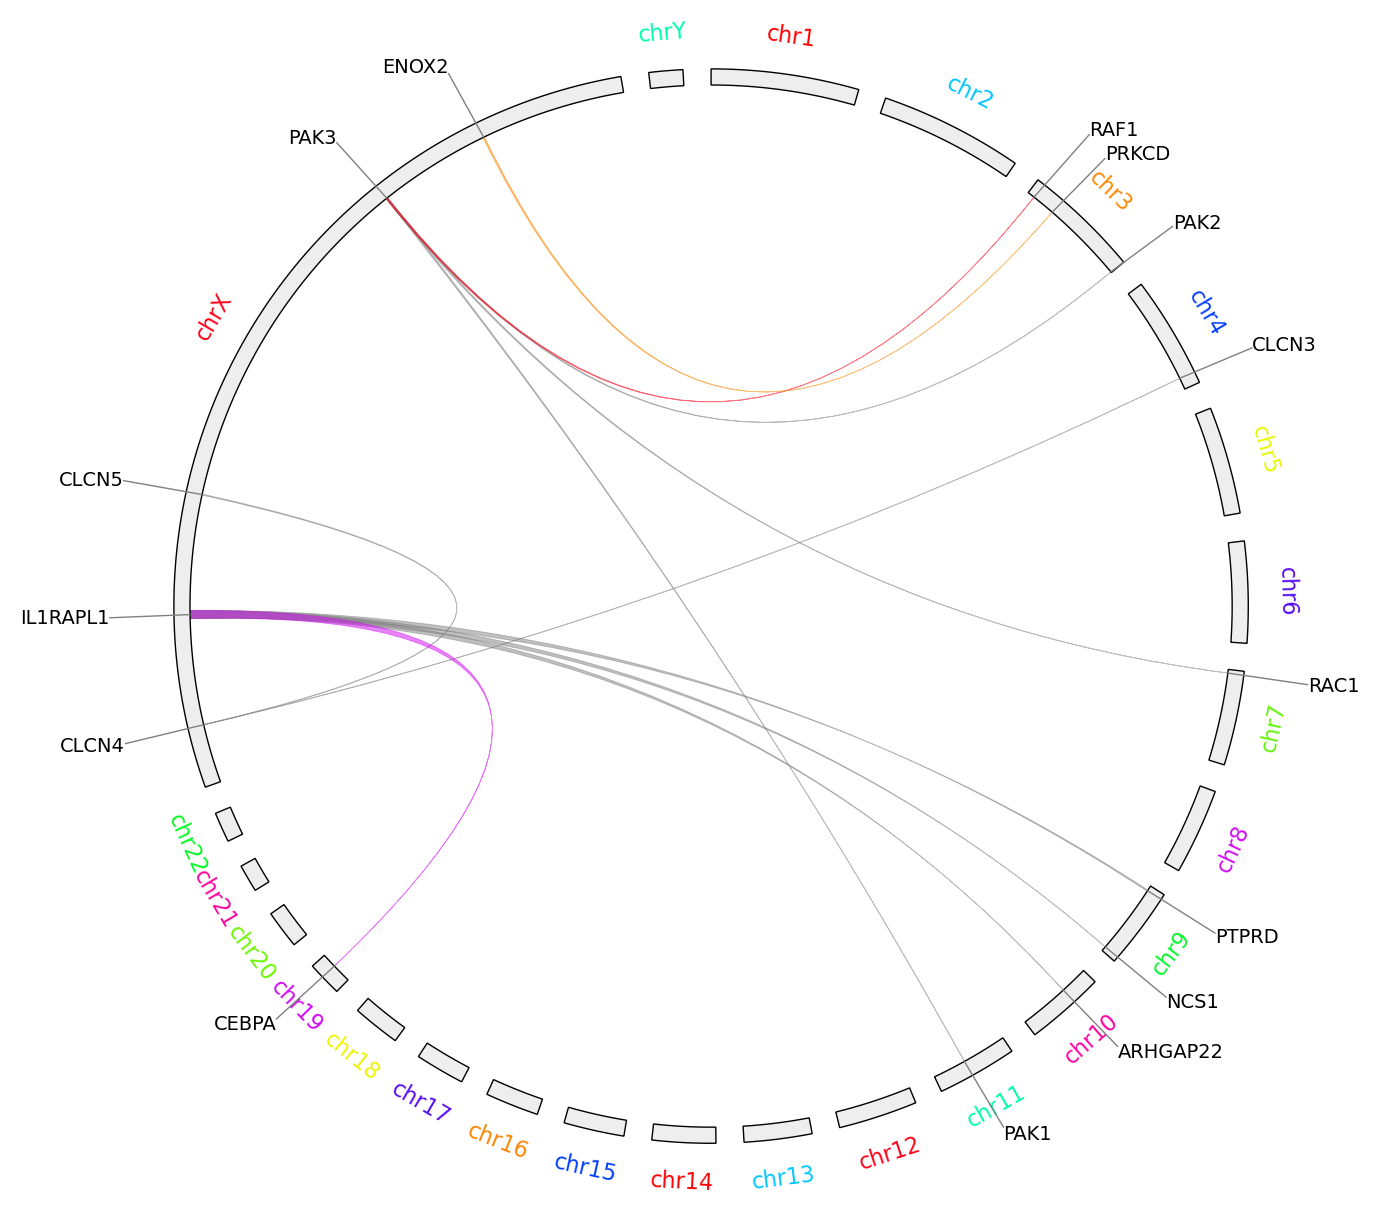

In [ ]:
# genes = query_genes(groups=r'PTM enzymes|ari_nonPUR|cDEG|cargo_gating|ech90_regions|hum_nean_admix|hybridDEG|linAR_human|nDEG|signalling/ion channel|tubulin_transport')
# genes = query_genes(groups=r'cDEG')
# genes = query_genes(groups=r'ari_nonPUR')

genes = sheet.get('ari_nonPUR') & (sheet.get('cDEG') | sheet.get('nDEG'))
print(genes)
stmts = cached_get_statements(genes,
                              confidence='supported',
                              parallel=4)
stmts = filter_statements(stmts)
reg = json.loads(Path(genes_path).read_text())
circos_plot(stmts,
            figsize=(7, 7),
            cmap = register_shifted_cmap('hsv'),
            scalings=dict(chrX=10),
            link_kwargs=dict(alpha=0.5, 
             lw=0.3)
            )

AFF2   CFAP47 CNKSR2 DIAPH2 ENOX2  FRMPD3 MID1   PAK3   PHKA2  RTL4   TSPAN7 


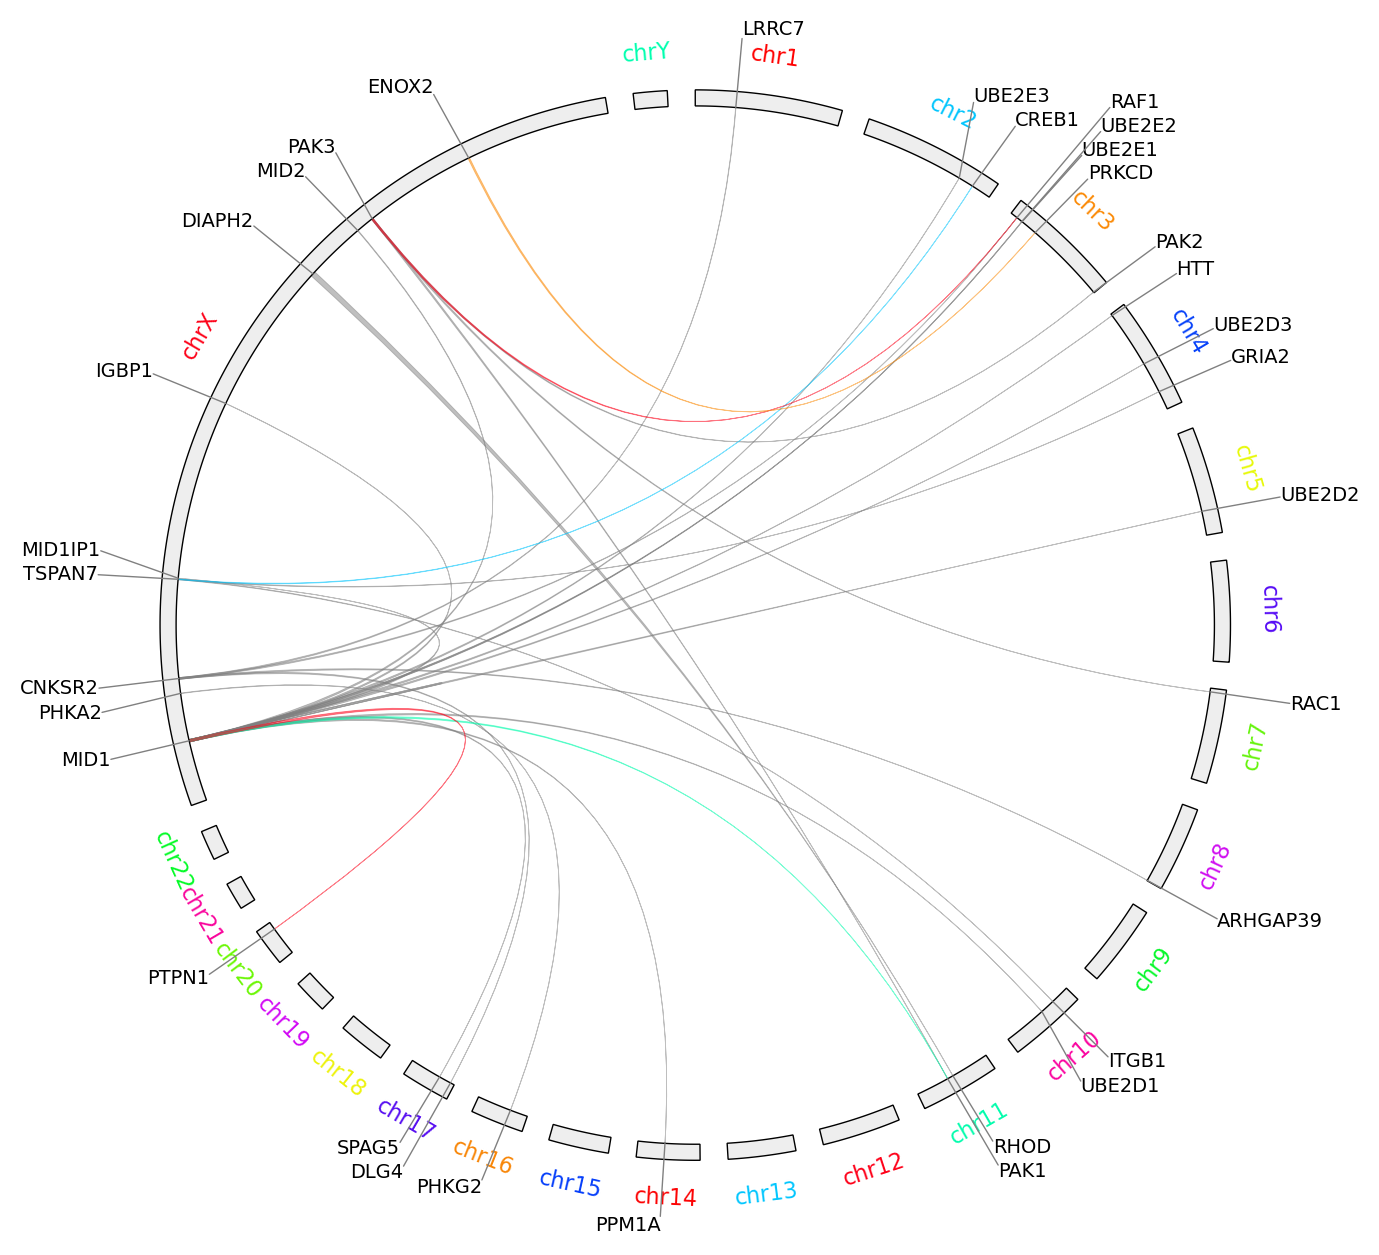

In [ ]:
genes = sheet.get('ari_relate_PUR') & (sheet.get('cDEG') | sheet.get('nDEG'))
print(genes)
stmts = cached_get_statements(genes,
                              confidence='supported',
                              parallel=4)
stmts = filter_statements(stmts)
reg = json.loads(Path(genes_path).read_text())
circos_plot(stmts,
            figsize=(7, 7),
            cmap = register_shifted_cmap('hsv'),
            scalings=dict(chrX=10),
            link_kwargs=dict(alpha=0.5, 
             lw=0.3)
            )

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
from matplotlib.colors import LinearSegmentedColormap

n_lines = 24
n = n_lines // 2
cmap = matplotlib.colormaps['hsv']
colors = cmap(np.linspace(0, 1, n))
l = list(range(n))
i = n//2
colors = [colors[x] for y in zip(l, l[i:] + l[:i]) for x in y][:n_lines]
_cmap = LinearSegmentedColormap.from_list('shifted_hsv', colors)
try:
    matplotlib.colormaps.register(cmap=_cmap)
except ValueError:
    pass




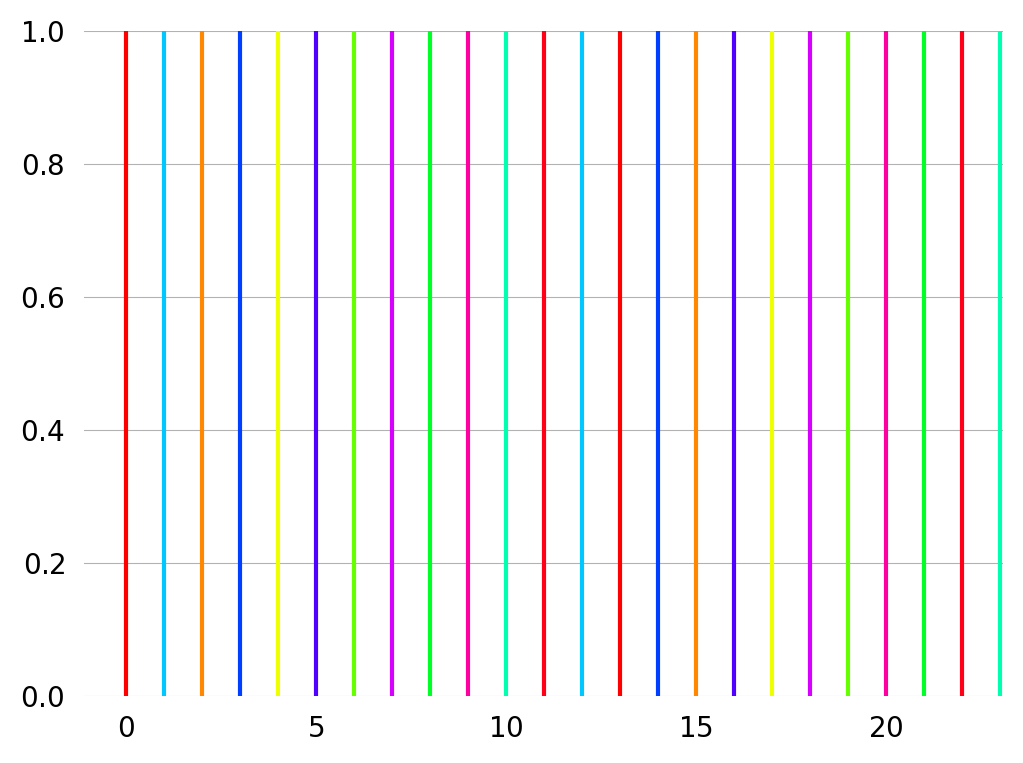

In [3]:

fig, ax = plt.subplots(layout='constrained')
for i, color in enumerate(colors):
    ax.axvline(i, color=color)
#    ax.plot([0, i], color=color)

plt.show()

In [ ]:

def circos_plot(genes=[], links={}, cmap=None, scalings={}):

    ColorCycler.set_cmap(cmap)

    # chr_bed_file, cytoband_file, chr_links = load_eukaryote_example_dataset("hg38")
    # circos = Circos.initialize_from_bed(chr_bed_file, space=3, link_kws=dict(lw=10))
    
    hg38_lengths = chrom_lengths['hg38'].copy()
    hg38_lengths['chrX'] *= 10

    circos = Circos(sectors=hg38_lengths, space=3)


    chr_names = [s.name for s in circos.sectors]
    colors = ColorCycler.get_color_list(len(chr_names))
    chr_name2color = {name: color for name, color in zip(chr_names, colors)}

    gene_info = defaultdict(list)
    for chrom, start, end, label in gene_coords(genes):
        gene_info[chrom].append(((start+end)/2, label))

    for sector in circos.sectors:
        ideogram_base = 97
        ideogram_height = 3
        sector.text(sector.name, r=105, size=8, color=chr_name2color[sector.name])
        outer_track = sector.add_track((ideogram_base, ideogram_base+ideogram_height))
        outer_track.axis(fc="#eeeeee")

        scale = scalings.get(sector.name, 1)

        pos_labels = gene_info.get(sector.name, [])
        for pos, label  in pos_labels:
            outer_track.annotate(pos * scale, label, label_size=7, 
                                min_r=ideogram_base, 
                                max_r=ideogram_base+5*ideogram_height,
                                # text_kws=dict(color='red')
                                )

    _from, _to = zip(*links)
    links = list(zip(gene_coords(_from), gene_coords(_to)))


    for a, b in links:
        _chrom = a[0]
        _from, _from_label = list(a[:3]), a[3]
        _from[1] *= scalings.get(_from[0], 1)
        _from[2] *= scalings.get(_from[0], 1)
        _to, _to_label = list(b[:3]), b[3]
        _to[1] *= scalings.get(_to[0], 1)
        _to[2] *= scalings.get(_to[0], 1)
        color = chr_name2color[_chrom]
        circos.link(_from, _to, 
                    color=color, 
                    lw=0.5, 
                    alpha=1,
                    zorder=0)

    figsize = (8, 8)

    # circos.savefig('circos_plot.pdf', figsize=figsize)
    fig = circos.plotfig(figsize=figsize)

cmap = register_shifted_cmap('tab20')
# cmap = 'tab10'

genes = ['ALG13', 'DYNLT3', 'MAF1', 'PRDM9']

links = [('ALG13', 'MAF1'), ('DYNLT3', 'PRDM9'), ('MAF1', 'PRDM9')]

circos_plot(genes=genes, links=links, cmap=cmap, scalings=dict(chrX=10))

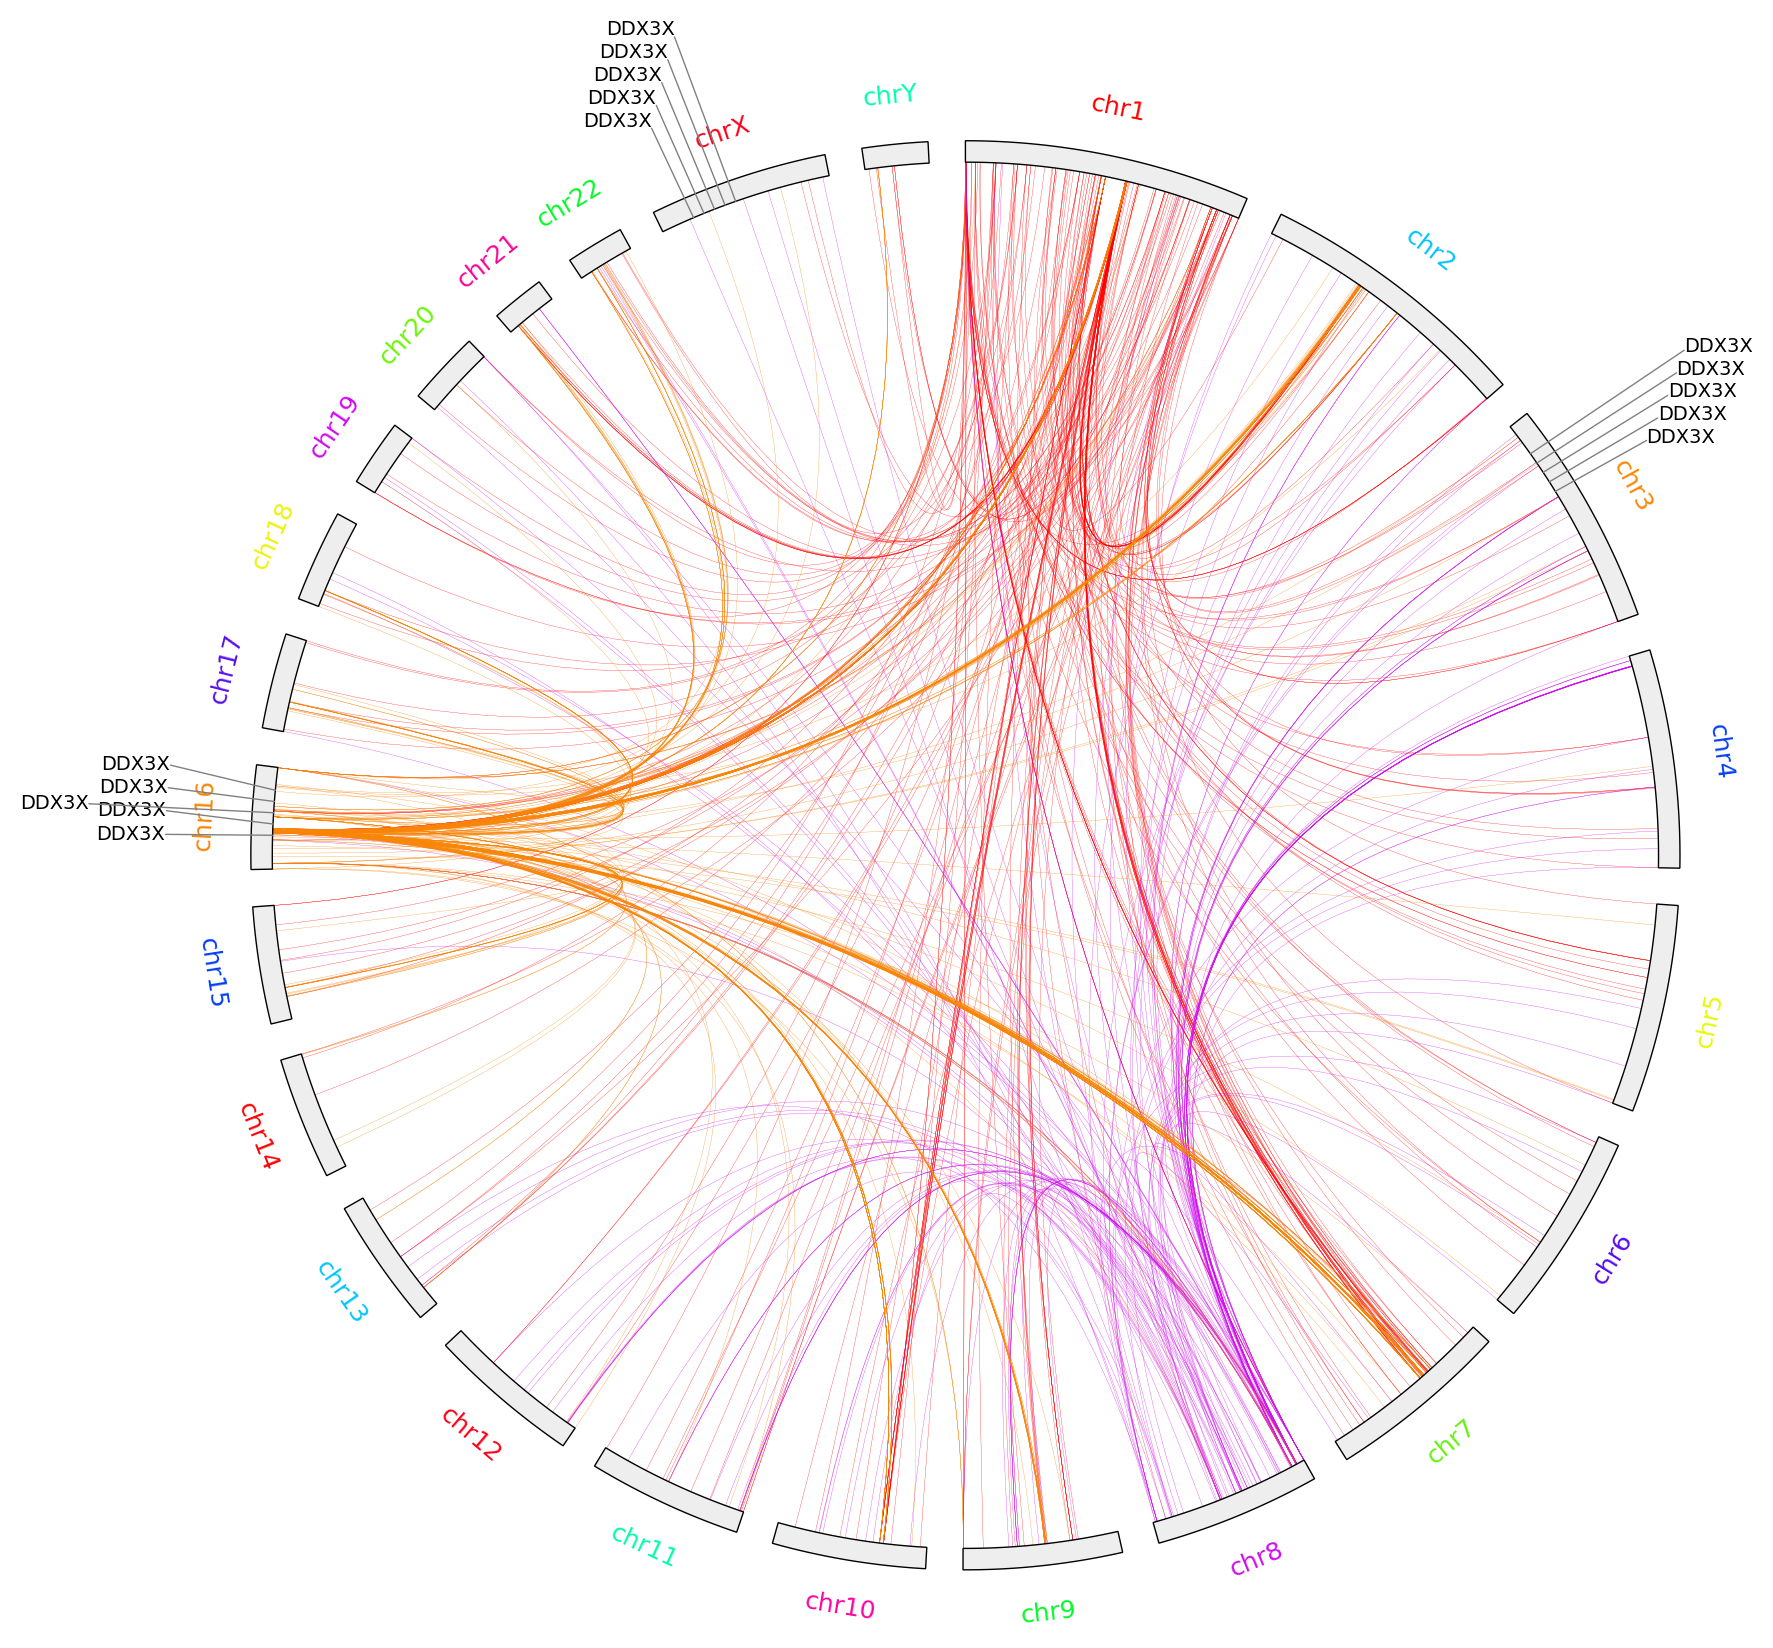

In [9]:

# circos = Circos(seqid2size, space=2)
chr_bed_file, cytoband_file, chr_links = load_eukaryote_example_dataset("hg38")
circos = Circos.initialize_from_bed(chr_bed_file, space=3)

# Create chromosome color dict
ColorCycler.set_cmap('shifted_hsv')
# ColorCycler.set_cmap('tab10')


chr_names = [s.name for s in circos.sectors]
colors = ColorCycler.get_color_list(len(chr_names))
chr_name2color = {name: color for name, color in zip(chr_names, colors)}

for sector in circos.sectors:

    # sector.text(sector.name, r=110, size=10, color=chr_name2color[sector.name])
    # outer_track = sector.add_track((99.7, 100))
    # outer_track.axis(fc="black")
    # major_interval = 50000000
    # minor_interval = int(major_interval / 5)
    # if sector.size > minor_interval:
    #     outer_track.xticks_by_interval(major_interval, label_formatter=lambda v: f"{v / 1000000:.0f}", label_orientation="vertical")
    #     outer_track.xticks_by_interval(minor_interval, tick_length=1, show_label=False)

    ideogram_base = 97
    ideogram_height = 3
    sector.text(sector.name, r=105, size=9, color=chr_name2color[sector.name])
    outer_track = sector.add_track((ideogram_base, ideogram_base+ideogram_height))
    outer_track.axis(fc="#eeeeee")


    if sector.name in ["chr3", 'chr16', 'chrX']:
        for i in range(5):

            label_pos = 20000000 + (i+1)*10000000
            label = "DDX3X"
            outer_track.annotate(label_pos, label, label_size=7, 
                                min_r=ideogram_base, 
                                max_r=ideogram_base+5*ideogram_height
                                )
        # label_pos = 50100000
        # label = "CFAP47"
        # outer_track.annotate(label_pos, label, label_size=7, 
        #                     min_r=ideogram_base, 
        #                     max_r=110
        #                      )

# Plot chromosome link
for link in chr_links:
    region1 = (link.query_chr, link.query_start, link.query_end)
    region2 = (link.ref_chr, link.ref_start, link.ref_end)
    color = chr_name2color[link.query_chr]
    if link.query_chr in ("chr1", "chr8", "chr16") and link.query_chr != link.ref_chr:
        circos.link(region1, region2, color=color)

figsize = (9, 9)

circos.savefig('circos_plot.pdf', figsize=figsize)
fig = circos.plotfig(figsize=figsize)

{'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309, 'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983, 'chr22': 50818468, 'chrX': 156040895, 'chrY': 57227415}


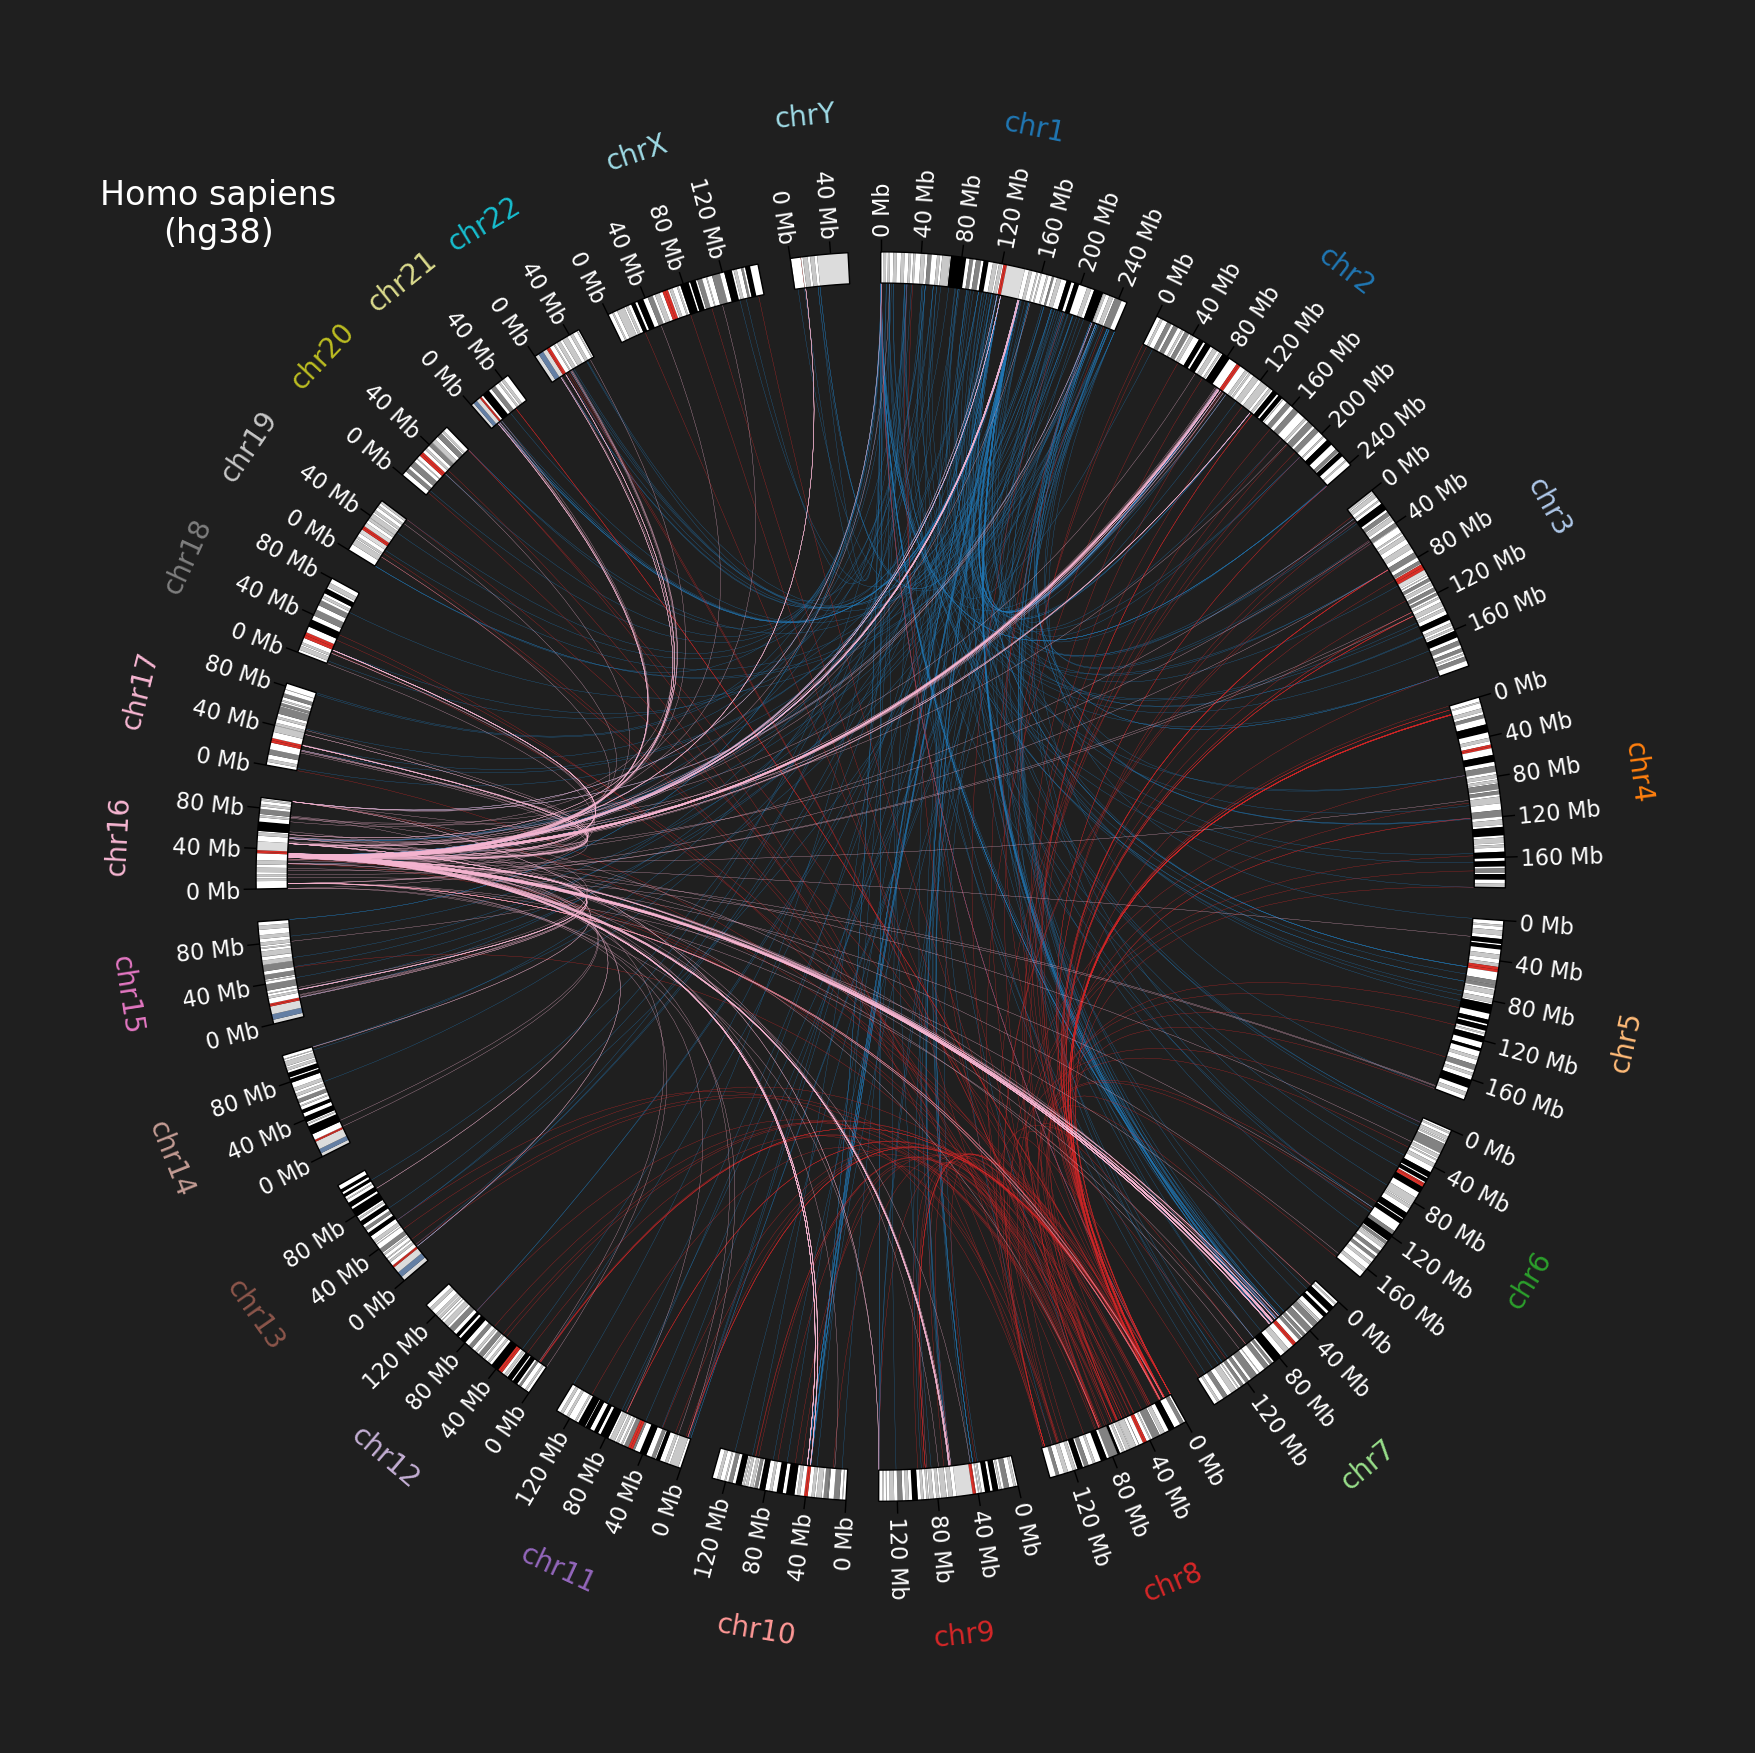

In [8]:

# Initialize Circos from BED chromosomes
circos = Circos.initialize_from_bed(chr_bed_file, space=3)
circos.text("Homo sapiens\n(hg38)", deg=315, r=150, size=12)

# Add cytoband tracks from cytoband file
circos.add_cytoband_tracks((95, 100), cytoband_file)

# Create chromosome color dict
ColorCycler.set_cmap("tab20")
chr_names = [s.name for s in circos.sectors]
colors = ColorCycler.get_color_list(len(chr_names))
chr_name2color = {name: color for name, color in zip(chr_names, colors)}

hg38sizes = {}

# Plot chromosome name & xticks
for sector in circos.sectors:
    hg38sizes[sector.name] = sector.size
    sector.text(sector.name, r=120, size=10, color=chr_name2color[sector.name])
    sector.get_track("cytoband").xticks_by_interval(
        40000000,
        label_size=8,
        label_orientation="vertical",
        label_formatter=lambda v: f"{v / 1000000:.0f} Mb",
    )
print(hg38sizes)
# Plot chromosome link
for link in chr_links:
    region1 = (link.query_chr, link.query_start, link.query_end)
    region2 = (link.ref_chr, link.ref_start, link.ref_end)
    color = chr_name2color[link.query_chr]
    if link.query_chr in ("chr1", "chr8", "chr16") and link.query_chr != link.ref_chr:
        circos.link(region1, region2, color=color)

fig = circos.plotfig()

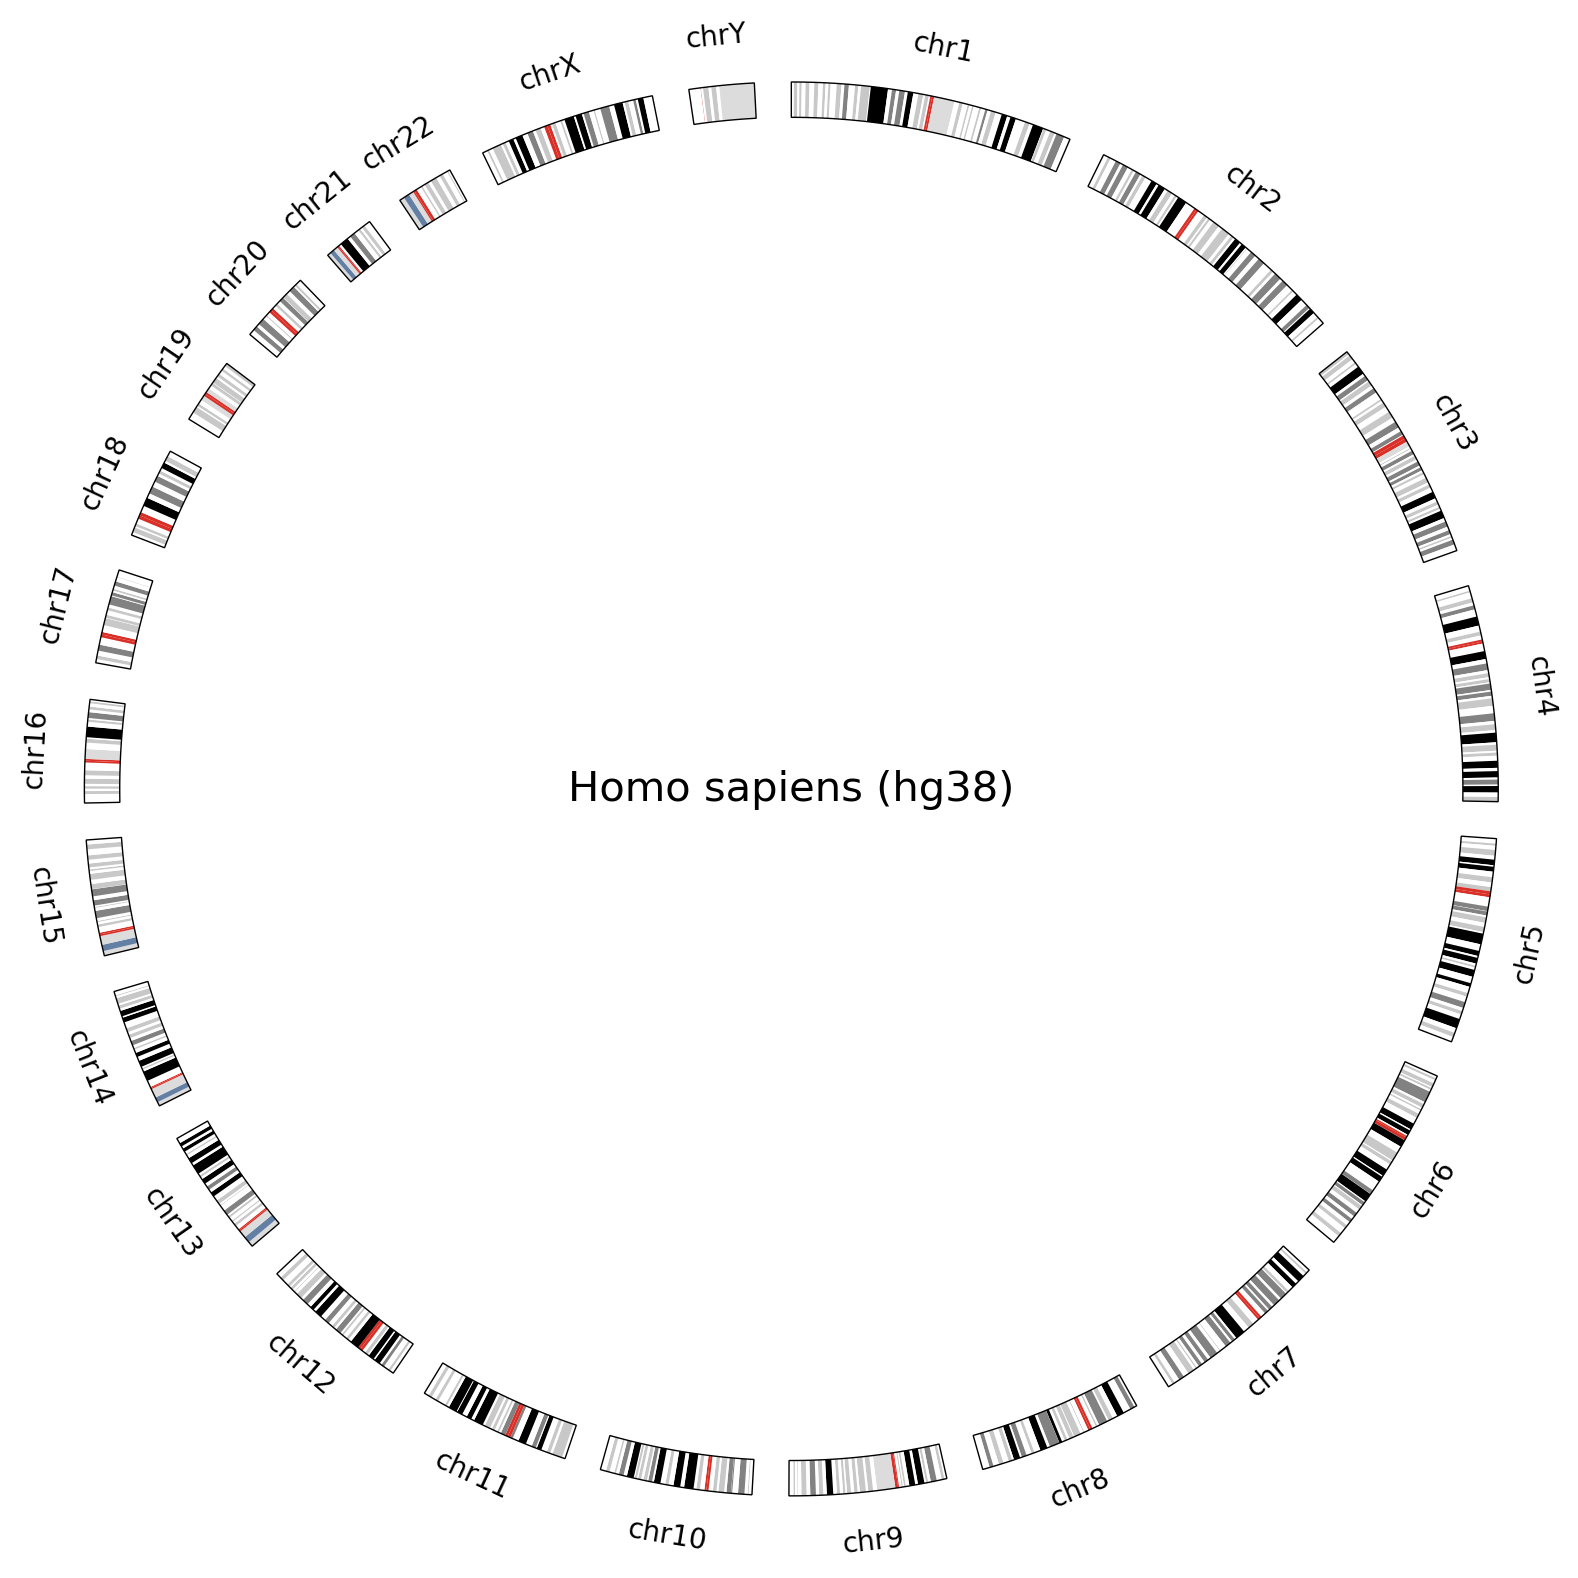

In [4]:
from pycirclize import Circos
from pycirclize.utils import load_eukaryote_example_dataset

# Load hg38 dataset (https://github.com/moshi4/pycirclize-data/tree/main/eukaryote/hg38)
chr_bed_file, cytoband_file, _ = load_eukaryote_example_dataset("hg38")

# Initialize Circos from BED chromosomes
circos = Circos.initialize_from_bed(chr_bed_file, space=3)
circos.text("Homo sapiens (hg38)", size=15)

# Add cytoband tracks from cytoband file
circos.add_cytoband_tracks((95, 100), cytoband_file)

# Plot chromosome name
for sector in circos.sectors:
    sector.text(sector.name, size=10)

fig = circos.plotfig()

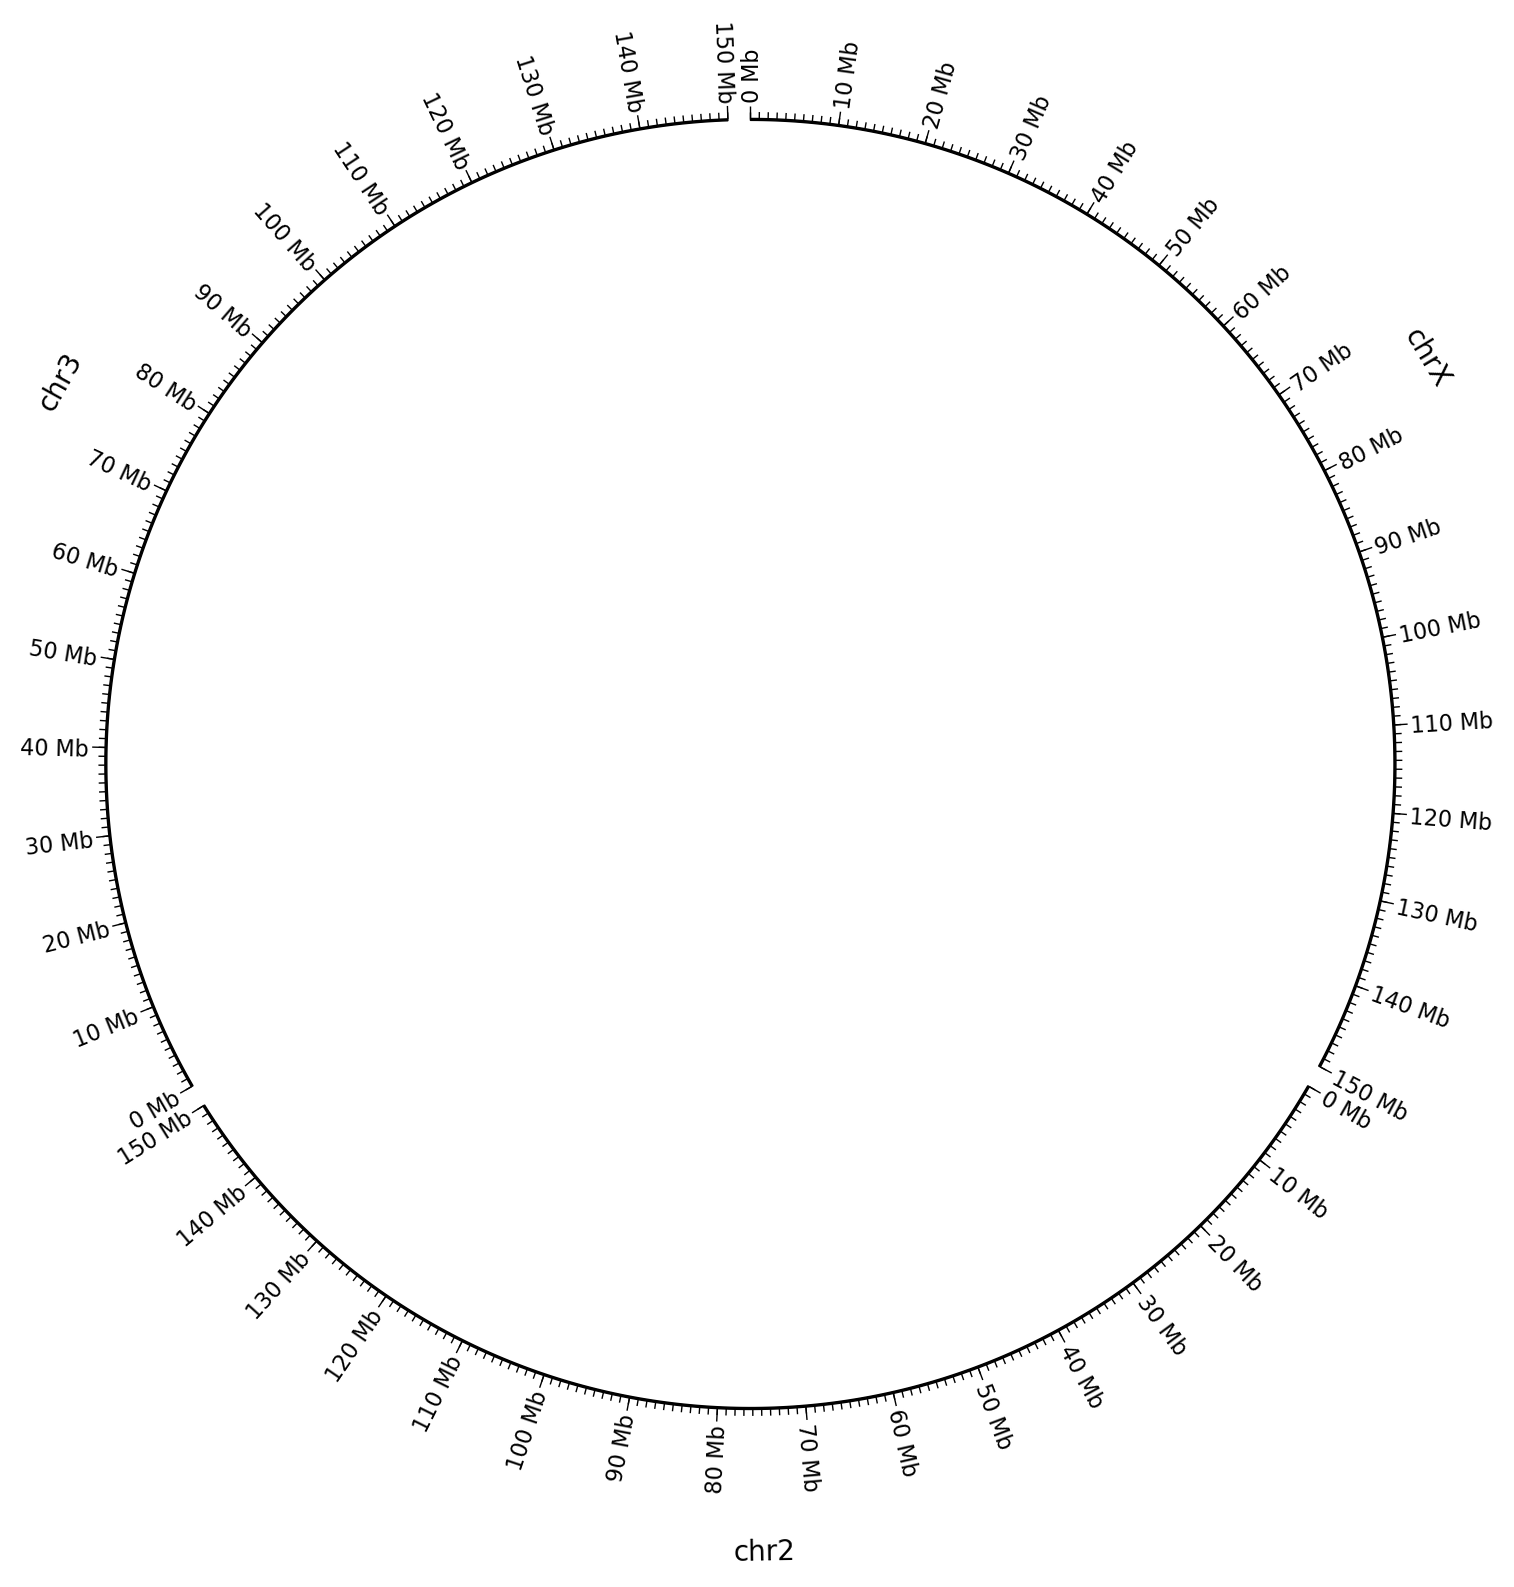

In [37]:
from pycirclize import Circos
from pycirclize.parser import Gff, Genbank
from pycirclize.utils import load_prokaryote_example_file
from matplotlib.patches import Patch

# Case1. Load `GFF` contig genomes
# https://github.com/moshi4/pycirclize-data/blob/main/prokaryote/mycoplasma_alvi.gff
gff_file = load_prokaryote_example_file("mycoplasma_alvi.gff")
parser = Gff(gff_file)

# Case2. Load `Genbank` contig genomes
# https://github.com/moshi4/pycirclize-data/blob/main/prokaryote/mycoplasma_alvi.gbk
# gbk_file = load_prokaryote_example_file("mycoplasma_alvi.gbk")
# parser = Genbank(gbk_file)

# Initialize circos instance
seqid2size = parser.get_seqid2size()
space = 0 if len(seqid2size) == 1 else 2

seqid2size = dict(chrX=150000000, chr2=150000000, chr3=150000000)

circos = Circos(seqid2size, space=space)
# Plot chromosome name
for sector in circos.sectors:
    sector.text(sector.name, r=120, size=10)

seqid2features = parser.get_seqid2features(feature_type=None)
for sector in circos.sectors:
    # Plot outer track
    outer_track = sector.add_track((99.7, 100))
    outer_track.axis(fc="black")
    major_interval = 10000000
    minor_interval = int(major_interval / 10)
    if sector.size > minor_interval:
        outer_track.xticks_by_interval(major_interval, label_formatter=lambda v: f"{v / 1000000:.0f} Mb", label_orientation="vertical")
        outer_track.xticks_by_interval(minor_interval, tick_length=1, show_label=False)


fig = circos.plotfig()



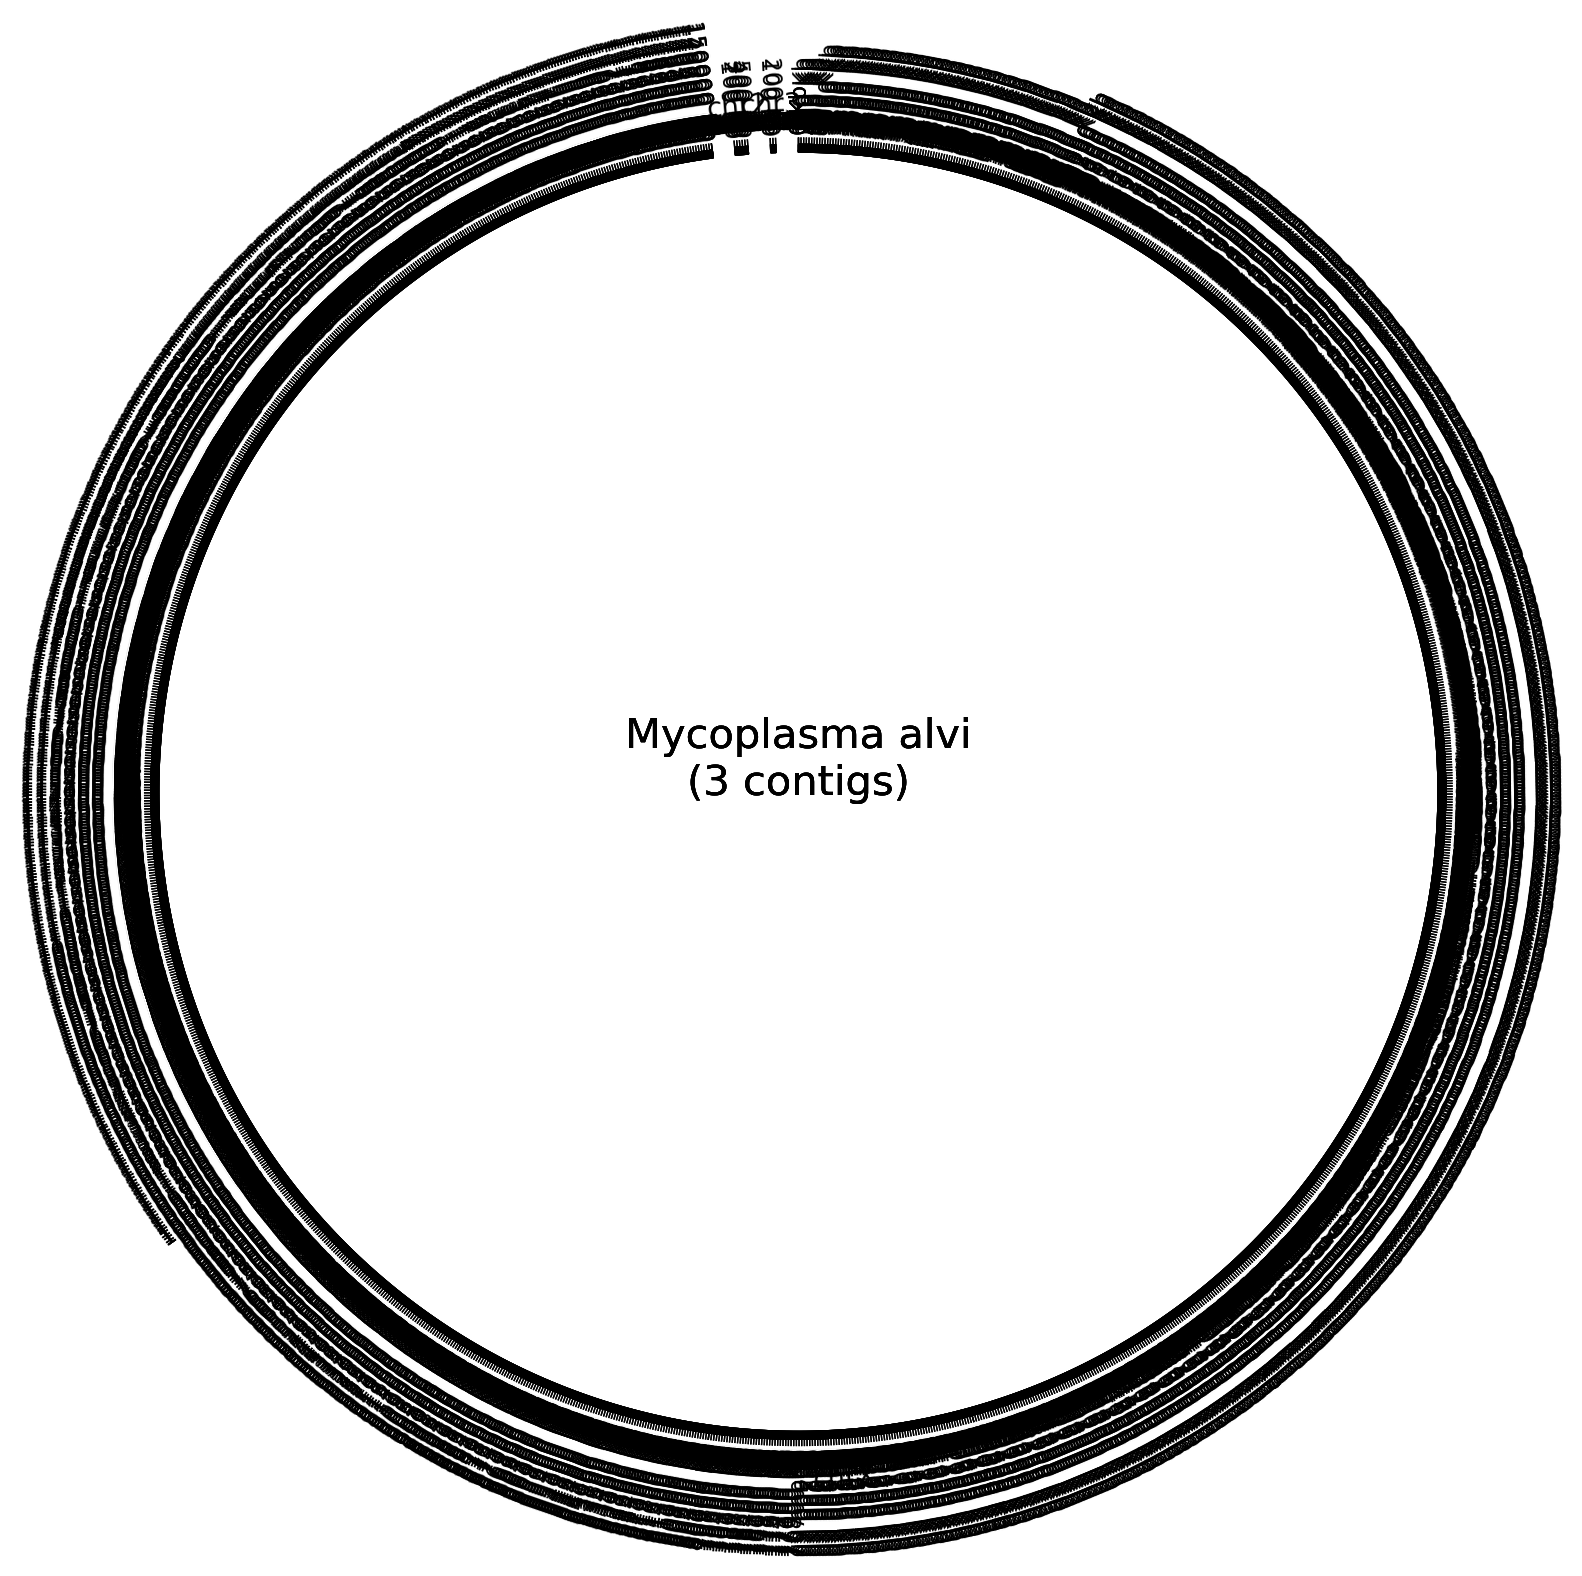

In [ ]:

circos.text(f"Mycoplasma alvi\n({len(circos.sectors)} contigs)", r=5, size=15)

seqid2features = parser.get_seqid2features(feature_type=None)
for sector in circos.sectors:
    # Plot outer track
    outer_track = sector.add_track((99.7, 100))
    outer_track.axis(fc="black")
    major_interval = 10000000
    minor_interval = int(major_interval / 10)
    if sector.size > minor_interval:
        outer_track.xticks_by_interval(major_interval, label_formatter=lambda v: f"{v / 1000:.0f} Kb",         label_orientation="vertical")
        outer_track.xticks_by_interval(minor_interval, tick_length=1, show_label=False)

    # # Plot forward/reverse CDS, rRNA, tRNA tracks
    # f_cds_track = sector.add_track((91, 98), r_pad_ratio=0.1)
    # r_cds_track = sector.add_track((84, 91), r_pad_ratio=0.1)
    # rrna_track = sector.add_track((77, 84), r_pad_ratio=0.1)
    # trna_track = sector.add_track((70, 77), r_pad_ratio=0.1)
    # for feature in seqid2features[sector.name]:
    #     if feature.type == "CDS":
    #         if feature.location.strand == 1:
    #             f_cds_track.genomic_features([feature], fc="tomato")
    #         else:
    #             r_cds_track.genomic_features([feature], fc="skyblue")
    #     elif feature.type == "rRNA":
    #         rrna_track.genomic_features([feature], fc="lime")
    #     elif feature.type == "tRNA":
    #         trna_track.genomic_features([feature], fc="magenta")

fig = circos.plotfig()
# _ = circos.ax.legend(
#     handles=[
#         Patch(color="tomato", label="Forward CDS"),
#         Patch(color="skyblue", label="Reverse CDS"),
#         Patch(color="lime", label="rRNA"),
#         Patch(color="magenta", label="tRNA"),
#     ],
#     bbox_to_anchor=(0.5, 0.45),
#     loc="center",
#     ncols=2,
# )